<a href="https://colab.research.google.com/github/Apollo355/movement-lab/blob/main/movement_lab_lesson_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mujoco
import mujoco
print("MuJoCo is installed and ready")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.7/232.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 16.3 MB/s eta 0:00:00
MuJoCo is installed and ready


In [2]:
import mujoco

# describe the robot: a single arm on a single hinge joint
xml = """
<mujoco>
  <worldbody>
    <body name="arm" pos="0 0 0">
      <joint name="hinge" type="hinge" axis="0 1 0"/>
      <geom type="capsule" size="0.05 0.5" rgba="0 0.6 1 1"/>
    </body>
  </worldbody>
</mujoco>
"""

model = mujoco.MjModel.from_xml_string(xml)   # MuJoCo reads the description, builds the robot
data  = mujoco.MjData(model)                  # holds the robot's live state (angles, positions)

print("Robot built.")
print("Number of joints:", model.njnt)

Robot built.
Number of joints: 1


In [5]:
!pip install mediapy # Install mediapy package

import mujoco
import mediapy as media   # Colab's tool for showing images/video

# point a camera at the robot and take one picture
renderer = mujoco.Renderer(model)
mujoco.mj_forward(model, data)      # compute the robot's current positions
renderer.update_scene(data)
pixels = renderer.render()

media.show_image(pixels)            # display the snapshot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 56.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
/usr/local/lib/python3.12/dist-packages/glfw/__init__.py:917: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)


FatalError: an OpenGL platform library has not been loaded into this process, this most likely means that a valid OpenGL context has not been created before mjr_makeContext was called

""

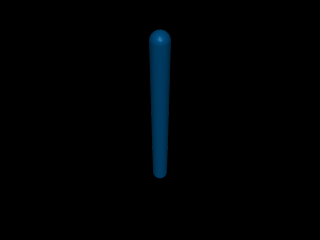

In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"   # tell MuJoCo to render off-screen (no monitor needed)

import mujoco
import mediapy as media

# rebuild the robot (fresh cell, so we redefine it)
xml = """
<mujoco>
  <worldbody>
    <body name="arm" pos="0 0 0">
      <joint name="hinge" type="hinge" axis="0 1 0"/>
      <geom type="capsule" size="0.05 0.5" rgba="0 0.6 1 1"/>
    </body>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(xml)
data  = mujoco.MjData(model)

# now render
renderer = mujoco.Renderer(model)
mujoco.mj_forward(model, data)
renderer.update_scene(data)
pixels = renderer.render()
media.show_image(pixels)

In [2]:
import numpy as np

# generate a swing: hinge angle going from 0 to 2 radians, over 60 frames
angles = np.linspace(0, 2, 60)

frames = []                          # we'll collect one picture per angle
for angle in angles:
    data.qpos[0] = angle             # set the hinge to this angle
    mujoco.mj_forward(model, data)   # update the robot's position
    renderer.update_scene(data)
    frames.append(renderer.render()) # snap a picture, add to the list

media.show_video(frames, fps=30)     # play the pictures back as video